In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
DATA_PATH = "Customer-Churn-Prediction-Lifetime-Value-Engine/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (7043, 21)


In [7]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\Amaan\OneDrive\Desktop\telecom
['04_model_comparison.ipynb', 'Customer-Churn-Prediction-Lifetime-Value-Engine', 'Telco_Customer_Churn_Mid_Review_Documentation.docx']


In [31]:
print("Columns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [32]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Missing TotalCharges before cleaning:",
      df["TotalCharges"].isnull().sum())

Missing TotalCharges before cleaning: 11


In [33]:
# Target variable
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Features
X = df.drop(
    ["customerID", "Churn"],
    axis=1
)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 19)
Target shape: (7043,)


In [34]:
print("Target distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(
    y.value_counts(normalize=True) * 100
)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Target percentage:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [35]:
X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

print("Encoded feature shape:", X_encoded.shape)

Encoded feature shape: (7043, 30)


In [36]:
X_encoded = X_encoded.fillna(X_encoded.mean()).astype(int)

print("Data types:")
print(X_encoded.dtypes.value_counts())

print("\nFinal feature shape:", X_encoded.shape)

Data types:
int32    30
Name: count, dtype: int64

Final feature shape: (7043, 30)


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 30)
X_test : (1409, 30)
y_train: (5634,)
y_test : (1409,)


In [38]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape :", X_test_scaled.shape)

Scaled training shape: (5634, 30)
Scaled testing shape : (1409, 30)


MODEL TRAINING

In [39]:
models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        max_depth=10,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
}

print("Models created successfully!")

for name in models:
    print("-", name)

Models created successfully!
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting


In [40]:
trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    # Fill NaN values in test set using training set mean
    X_train_filled = X_train.fillna(X_train.mean())
    X_test_filled = X_test.fillna(X_train.mean())
    
    # Scale the data
    scaler_temp = StandardScaler()
    X_train_scaled_temp = scaler_temp.fit_transform(X_train_filled)
    X_test_scaled_temp = scaler_temp.transform(X_test_filled)
    
    model.fit(X_train_scaled_temp, y_train)

    trained_models[name] = model

    print(f"{name} training completed!")

print("\nAll models trained successfully!")

Training Logistic Regression...
Logistic Regression training completed!
Training Decision Tree...
Decision Tree training completed!
Training Random Forest...
Random Forest training completed!
Training Gradient Boosting...
Gradient Boosting training completed!

All models trained successfully!


MODEL EVALUATION

In [41]:
results = []

for name, model in trained_models.items():

    y_pred = model.predict(X_test_scaled_temp)
    y_prob = model.predict_proba(X_test_scaled_temp)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )
    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195,0.841499
1,Decision Tree,0.794180,0.630435,0.542781,0.583333,0.826517
2,Random Forest,0.799858,0.657534,0.513369,0.576577,0.839487
3,Gradient Boosting,0.795600,0.644295,0.513369,0.571429,0.843474


In [42]:
results_display = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

for column in metric_columns:
    results_display[column] = (
        results_display[column] * 100
    ).round(2)

print("Model Comparison Results:")
display(results_display)

Model Comparison Results:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,80.70,65.84,56.68,60.92,84.15
1,Decision Tree,79.42,63.04,54.28,58.33,82.65
2,Random Forest,79.99,65.75,51.34,57.66,83.95
3,Gradient Boosting,79.56,64.43,51.34,57.14,84.35


MODEL COMPARISON GRAPHS

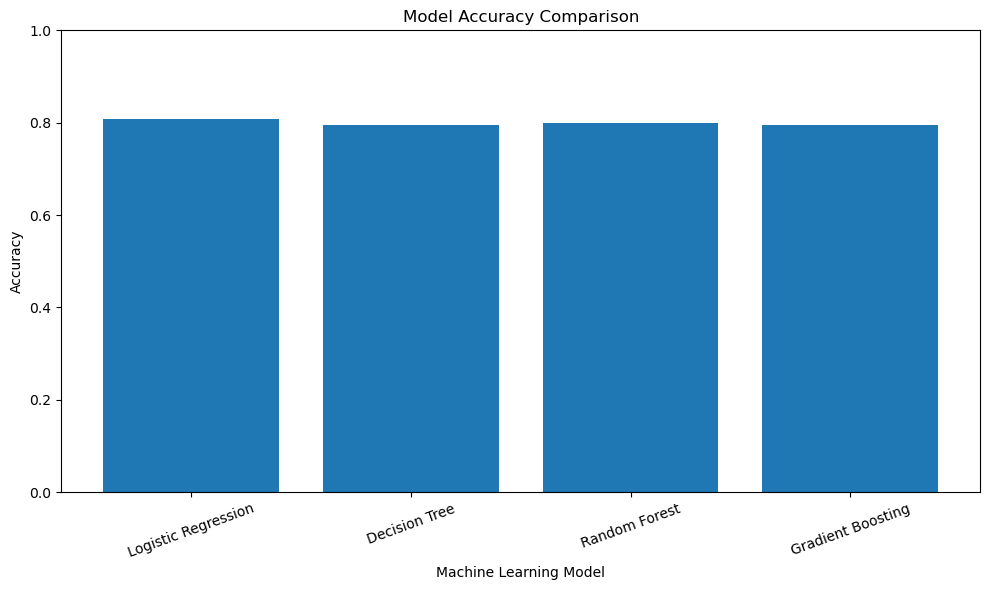

In [43]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

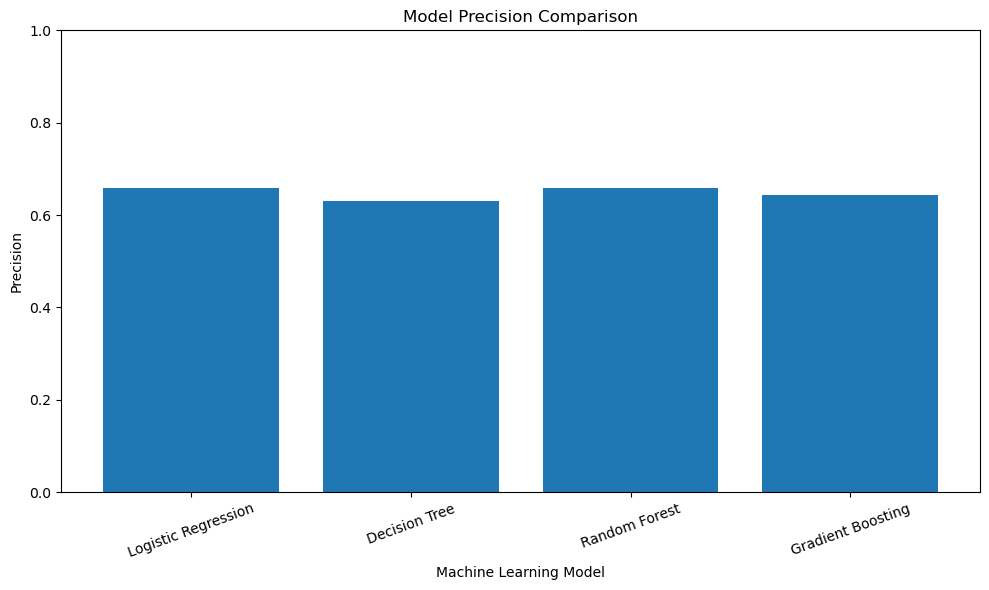

In [44]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["Precision"]
)

plt.title("Model Precision Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Precision")

plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

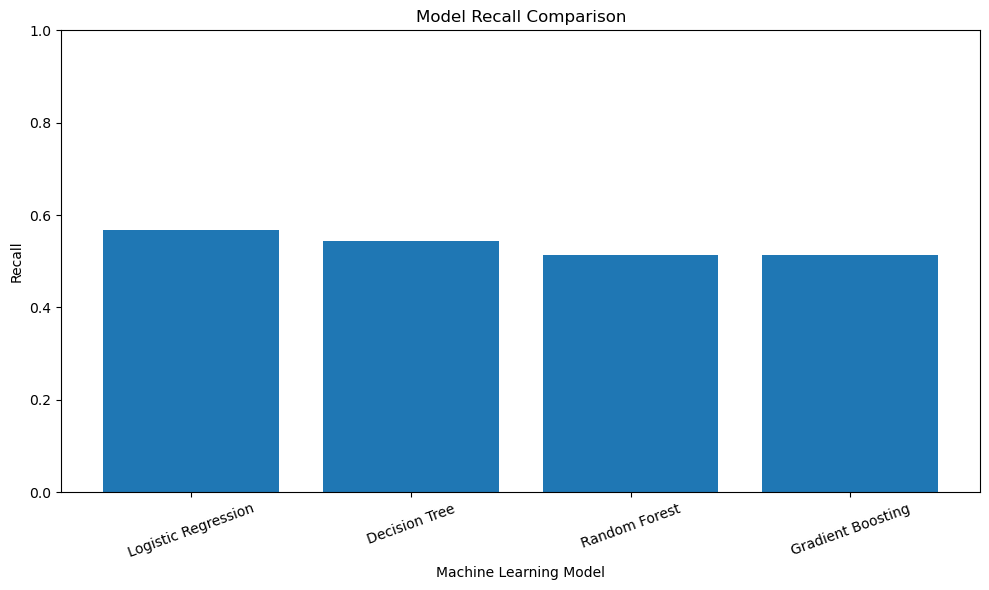

In [45]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["Recall"]
)

plt.title("Model Recall Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Recall")

plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

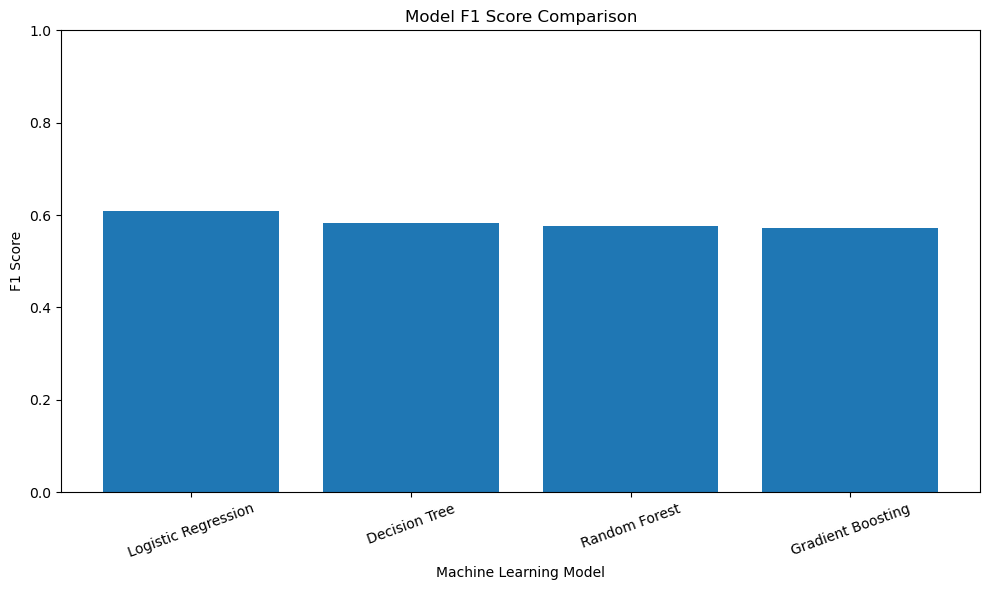

In [46]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["F1 Score"]
)

plt.title("Model F1 Score Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("F1 Score")

plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

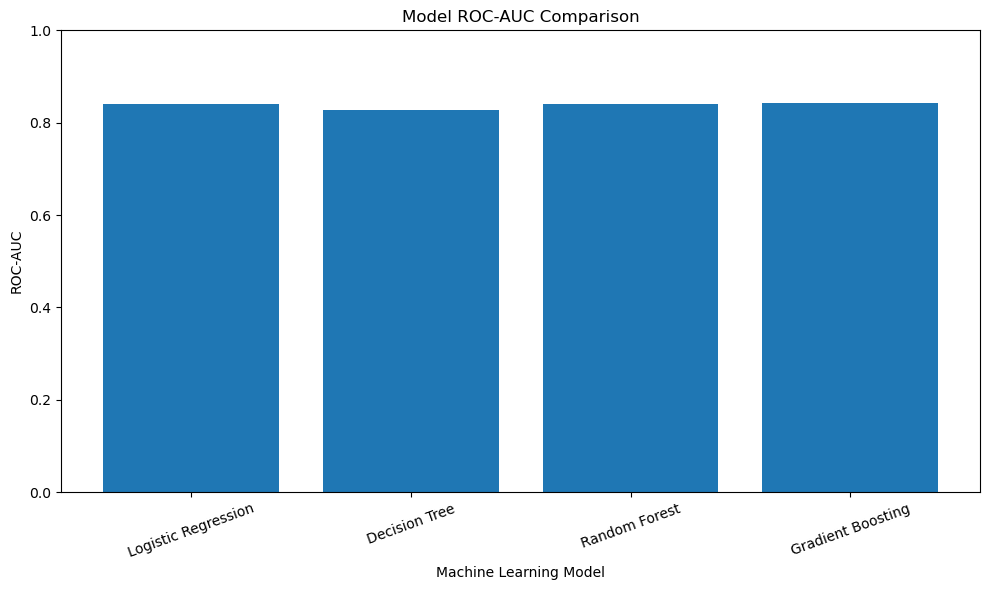

In [47]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["ROC-AUC"]
)

plt.title("Model ROC-AUC Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("ROC-AUC")

plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

ROC CURVE

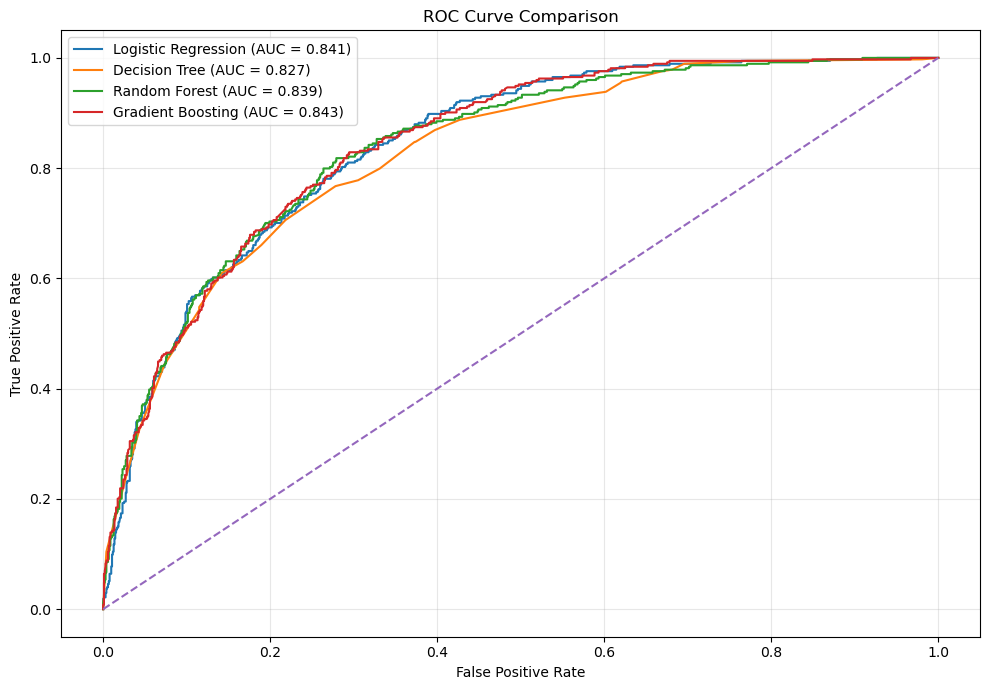

In [48]:
plt.figure(figsize=(10, 7))

for name, model in trained_models.items():

    y_prob = model.predict_proba(X_test_scaled_temp)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
for name, model in trained_models.items():

    y_pred = model.predict(X_test_scaled_temp)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(cm)


Logistic Regression
[[925 110]
 [162 212]]

Decision Tree
[[916 119]
 [171 203]]

Random Forest
[[935 100]
 [182 192]]

Gradient Boosting
[[929 106]
 [182 192]]


In [50]:
for name, model in trained_models.items():

    y_pred = model.predict(X_test_scaled_temp)

    print("\n")
    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "No Churn",
                "Churn"
            ],
            zero_division=0
        )
    )



Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



Decision Tree
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



Random Forest
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0

In [51]:
best_f1_index = results_df["F1 Score"].idxmax()

best_f1_model_name = results_df.loc[
    best_f1_index,
    "Model"
]

best_f1_score = results_df.loc[
    best_f1_index,
    "F1 Score"
]

best_auc_index = results_df["ROC-AUC"].idxmax()

best_auc_model_name = results_df.loc[
    best_auc_index,
    "Model"
]

best_auc_score = results_df.loc[
    best_auc_index,
    "ROC-AUC"
]

print("Best model based on F1 Score:")
print(best_f1_model_name)
print(f"F1 Score: {best_f1_score:.4f}")

print("\nBest model based on ROC-AUC:")
print(best_auc_model_name)
print(f"ROC-AUC: {best_auc_score:.4f}")

Best model based on F1 Score:
Logistic Regression
F1 Score: 0.6092

Best model based on ROC-AUC:
Gradient Boosting
ROC-AUC: 0.8435


In [52]:
best_model_name = best_f1_model_name
best_model = trained_models[best_model_name]

best_row = results_df[
    results_df["Model"] == best_model_name
].iloc[0]

print("=" * 60)
print("FINAL MODEL SELECTION")
print("=" * 60)

print(f"Selected Model : {best_model_name}")
print(f"Accuracy       : {best_row['Accuracy']:.4f}")
print(f"Precision      : {best_row['Precision']:.4f}")
print(f"Recall         : {best_row['Recall']:.4f}")
print(f"F1 Score       : {best_row['F1 Score']:.4f}")
print(f"ROC-AUC        : {best_row['ROC-AUC']:.4f}")

FINAL MODEL SELECTION
Selected Model : Logistic Regression
Accuracy       : 0.8070
Precision      : 0.6584
Recall         : 0.5668
F1 Score       : 0.6092
ROC-AUC        : 0.8415


In [53]:
import os

os.makedirs("../data", exist_ok=True)

results_df.to_csv(
    "../data/model_comparison_results.csv",
    index=False
)

print(
    "Model comparison results saved successfully!"
)

Model comparison results saved successfully!
